In [76]:
import pandas as pd                        
import numpy as np                         
import matplotlib.pyplot as plt             
import seaborn as sns 


In [77]:
df=pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [78]:
print("Column names:")
print(df.columns.tolist())
print()

Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']



In [79]:
print("\nDataFrame Info:")
df.info()
print()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12 

In [80]:
print("\nSummary Statistics for Categorical Columns:")
display(df.describe(include='object'))


Summary Statistics for Categorical Columns:


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


In [81]:
for col in df.describe(include = 'object').columns:
    print(col)
    print(df[col].unique())
    print('`'*50)

hotel
['Resort Hotel' 'City Hotel']
``````````````````````````````````````````````````
arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
``````````````````````````````````````````````````
meal
['BB' 'FB' 'HB' 'SC' 'Undefined']
``````````````````````````````````````````````````
country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST'
 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR'
 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO'
 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM'
 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY'
 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN'
 'SYC' 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB'
 'CMR' 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'J

In [82]:
print("Missing values per column:")
print(df.isnull().sum())
print()

Missing values per column:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                         

<Axes: >

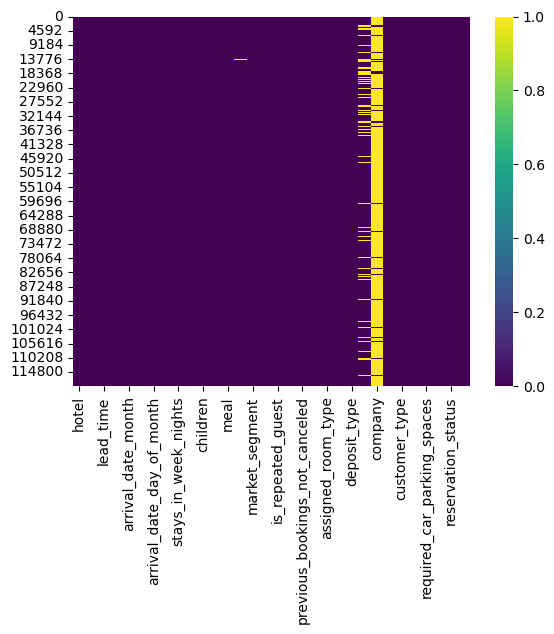

In [83]:
sns.heatmap(df.isnull(),cmap = 'viridis')

In [84]:
cols_to_drop = ['agent', 'company']
df.drop(cols_to_drop, axis=1, inplace=True)
print(f"Dropped columns: {cols_to_drop}")

Dropped columns: ['agent', 'company']


In [85]:
df.dropna(inplace=True)
print(f"Data shape after dropping NA: {df.shape}")

Data shape after dropping NA: (118898, 30)


In [86]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")
duplicate_rows

Number of duplicate rows: 31984


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,0.0,0,BB,SWE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [87]:
df.drop_duplicates(inplace=True)
print(f"Data shape after removing duplicates: {df.shape}")

Data shape after removing duplicates: (86914, 30)


In [88]:
print("\nSummary statistics for numerical columns:")
display(df.describe())


Summary statistics for numerical columns:


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000,86914.000000
mean,0.275939,80.202741,2016.211842,26.841694,15.818453,1.007548,2.628955,1.878604,0.139253,0.010815,0.039246,0.030237,0.176761,0.271912,0.753722,106.580816,0.083473,0.699542
std,0.446989,86.102902,0.685989,13.654113,8.834539,1.028821,2.043860,0.625881,0.456848,0.113510,0.194180,0.369629,1.718139,0.728177,10.043309,54.959600,0.280440,0.831880
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,12.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.250000,0.000000,0.000000
50%,0.000000,50.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.410000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.100000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


In [90]:
# Calculate the average lead time for each hotel type
avg_lead_time_by_hotel = df.groupby('hotel')['lead_time'].mean()

# Display the result
print("Average Lead Time by Hotel Type:")
print(avg_lead_time_by_hotel)

Average Lead Time by Hotel Type:
hotel
City Hotel      77.690323
Resort Hotel    84.206714
Name: lead_time, dtype: float64


In [95]:

df['is_family'] = df.apply(
    lambda row: 'group' if row['adults'] > 2 else (
        'full_family' if row['adults'] > 2 and (row['children'] > 0 or row['babies'] > 0) else (
            'family' if row['adults'] in [1, 2] and (row['children'] > 0 or row['babies'] > 0) else (
                'double' if row['adults'] == 2 else 'single'
            )
        )
    ), axis=1
)


In [97]:
family_counts = df['is_family'].value_counts()
print("Total number of each family type:")
print(family_counts)

print("Total cancellation rate of each family type:")
df.groupby('is_family')['is_canceled'].mean()

Total number of each family type:
is_family
double    56425
single    16149
family     8334
group      6006
Name: count, dtype: int64
Total cancellation rate of each family type:


is_family
double    0.282463
family    0.337893
group     0.342491
single    0.196421
Name: is_canceled, dtype: float64

In [98]:
full_family_exists = (df['is_family'] == 'full_family').any()
print(f"Is there any full family? {full_family_exists}")

Is there any full family? False


In [100]:
df.groupby(['hotel'])['is_canceled'].sum()

hotel
City Hotel      16039
Resort Hotel     7944
Name: is_canceled, dtype: int64

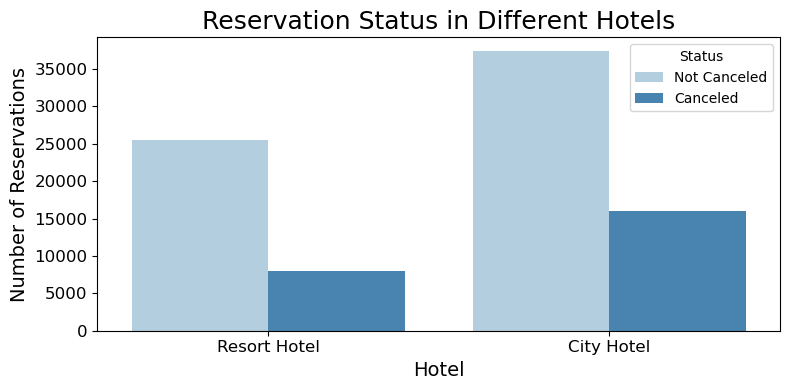

In [99]:
plt.figure(figsize=(8, 4))
ax1 = sns.countplot(
    x='hotel',
    hue='is_canceled',
    data=df,
    palette='Blues'
)

# Set legend outside the plot for clarity
ax1.legend_.set_bbox_to_anchor((1, 1))
plt.title('Reservation Status in Different Hotels', fontsize=18)
plt.xlabel('Hotel', fontsize=14)
plt.ylabel('Number of Reservations', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(['Not Canceled', 'Canceled'], title='Status', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [101]:
def lead_time_category(x):
    if x < 7:
        return 'Last_Minute'
    elif x < 30:
        return 'Short_Term'
    elif x < 90:
        return 'Mid_Term'
    else:
        return 'Long_Term'

df['lead_time_category'] = df['lead_time'].apply(lead_time_category)

In [102]:
canceled_data = df[df['is_canceled'] == 1].groupby('lead_time_category').size()
print("Total canceled data based on lead_time_category:")
print(canceled_data)

Total canceled data based on lead_time_category:
lead_time_category
Last_Minute     1372
Long_Term      11119
Mid_Term        7371
Short_Term      4121
dtype: int64


In [ ]:
# Group by lead_time_category and is_family, then sum the is_canceled column
cancellation_summary = df.groupby(['lead_time_category', 'is_family'])['is_canceled'].sum()

# Display the result
print("Total cancellations for each family type within each lead time category:")
print(cancellation_summary)


Total cancellations for each family type within each lead time category:
lead_time_category  is_family
Last_Minute         double        734
                    family         90
                    group          57
                    single        491
Long_Term           double       7709
                    family       1388
                    group        1029
                    single        993
Mid_Term            double       4877
                    family        903
                    group         697
                    single        894
Short_Term          double       2618
                    family        435
                    group         274
                    single        794
Name: is_canceled, dtype: int64


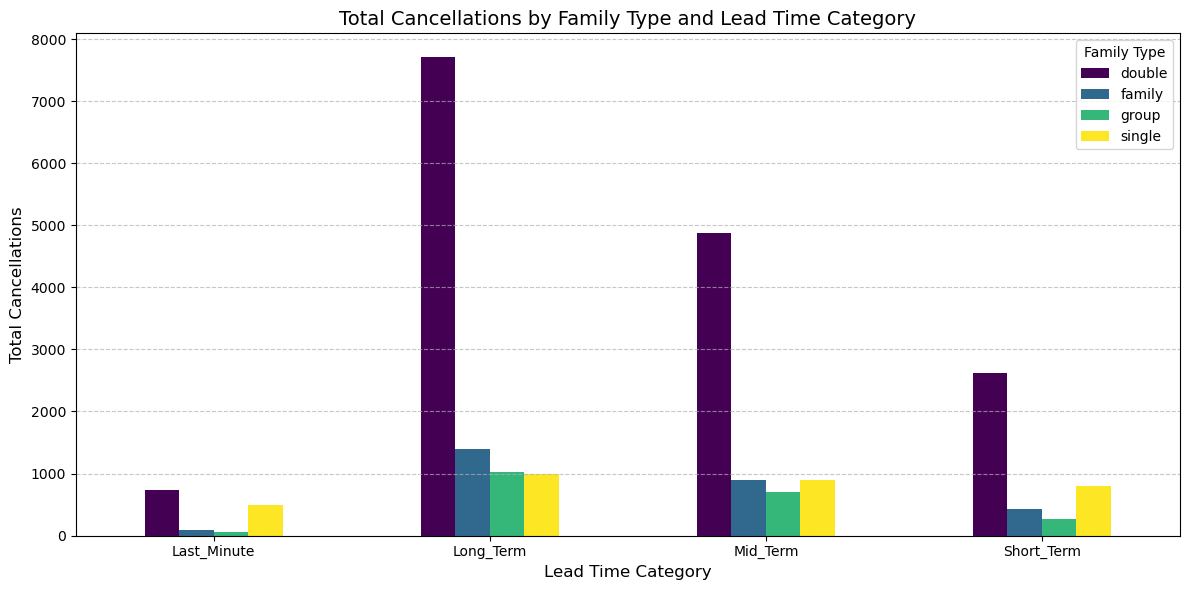

In [71]:
# Unstack the cancellation_summary for better visualization
cancellation_summary_unstacked = cancellation_summary.unstack()

# Plot the grouped bar chart
cancellation_summary_unstacked.plot(kind='bar', figsize=(12, 6), colormap='viridis')

# Add labels and title
plt.title('Total Cancellations by Family Type and Lead Time Category', fontsize=14)
plt.xlabel('Lead Time Category', fontsize=12)
plt.ylabel('Total Cancellations', fontsize=12)
plt.legend(title='Family Type', fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [104]:
cancel_by_lead = df.groupby('lead_time_category')['is_canceled'].mean()
print(cancel_by_lead)

lead_time_category
Last_Minute    0.081618
Long_Term      0.367789
Mid_Term       0.320897
Short_Term     0.243817
Name: is_canceled, dtype: float64


In [105]:
correlation = df[['lead_time', 'is_canceled']].corr()
print(correlation)

             lead_time  is_canceled
lead_time     1.000000     0.183683
is_canceled   0.183683     1.000000


In [106]:
print(df['lead_time'].describe())

outliers = df[df['lead_time'] > 300]
print(f"Outliers count: {len(outliers)}")

count    86914.000000
mean        80.202741
std         86.102902
min          0.000000
25%         12.000000
50%         50.000000
75%        125.000000
max        737.000000
Name: lead_time, dtype: float64
Outliers count: 2286


In [107]:
top_countries = df['country'].value_counts().head(10)
print(top_countries)

country
PRT    27436
GBR    10431
FRA     8837
ESP     7250
DEU     5385
ITA     3065
IRL     3016
BEL     2081
BRA     1993
NLD     1911
Name: count, dtype: int64


In [108]:
import numpy as np

cancel_rate = np.sum(df['is_canceled']) / len(df)
print(f"Overall cancellation rate: {cancel_rate}")

Overall cancellation rate: 0.2759394343834135


In [113]:
df.groupby('hotel')['is_canceled'].mean()


hotel
City Hotel      0.300333
Resort Hotel    0.237064
Name: is_canceled, dtype: float64

In [114]:

df.groupby('deposit_type')['is_canceled'].mean()


deposit_type
No Deposit    0.267868
Non Refund    0.946962
Refundable    0.242991
Name: is_canceled, dtype: float64

In [115]:

df.groupby('market_segment')['is_canceled'].mean()


market_segment
Aviation         0.198238
Complementary    0.123209
Corporate        0.123478
Direct           0.147960
Groups           0.270462
Offline TA/TO    0.148314
Online TA        0.353999
Name: is_canceled, dtype: float64

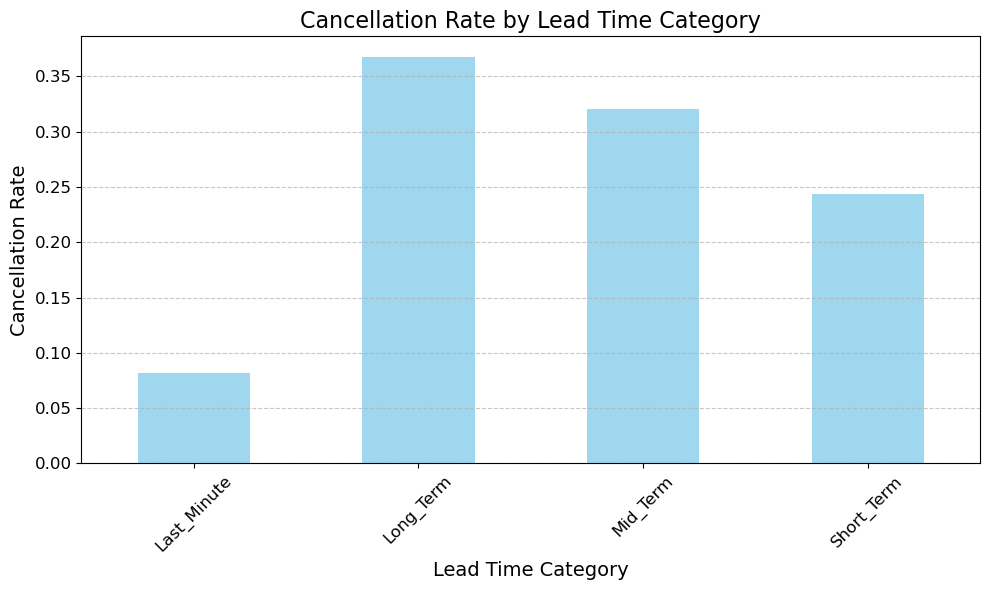

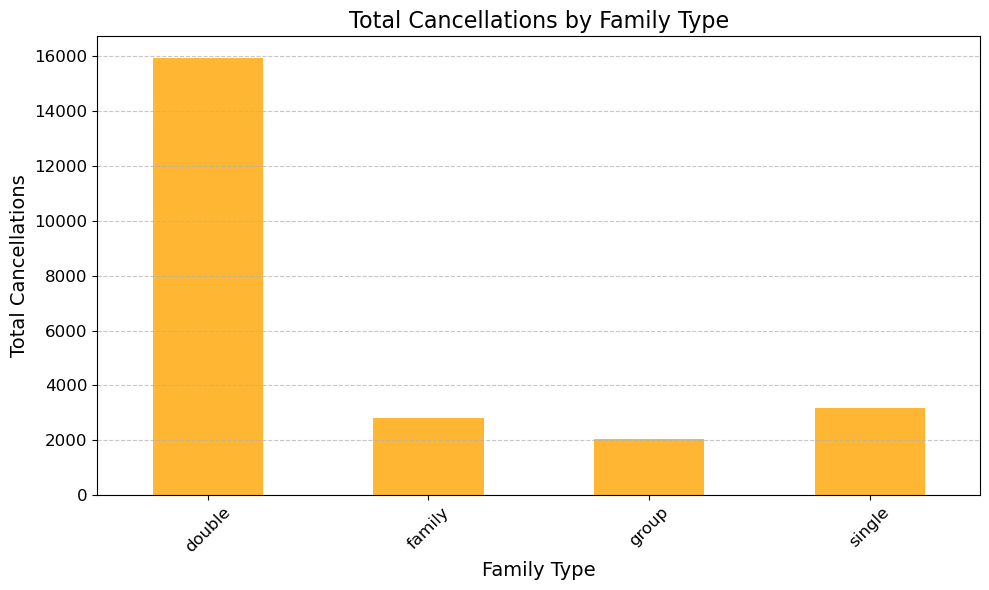

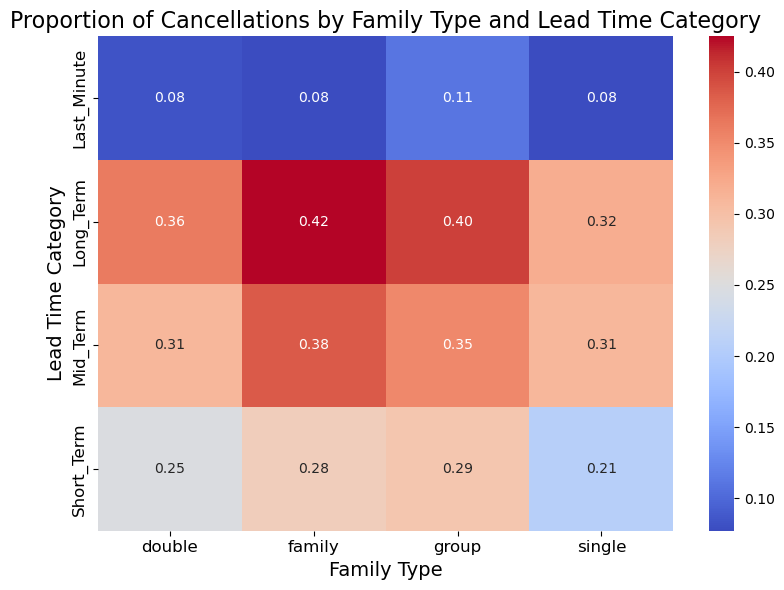

In [117]:
# Plot the cancellation rate by lead time category
plt.figure(figsize=(10, 6))
cancel_by_lead.plot(kind='bar', color='skyblue', alpha=0.8)
plt.title('Cancellation Rate by Lead Time Category', fontsize=16)
plt.xlabel('Lead Time Category', fontsize=14)
plt.ylabel('Cancellation Rate', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot the total cancellations by family type
plt.figure(figsize=(10, 6))
canceled_by_family.plot(kind='bar', color='orange', alpha=0.8)
plt.title('Total Cancellations by Family Type', fontsize=16)
plt.xlabel('Family Type', fontsize=14)
plt.ylabel('Total Cancellations', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot the relation table as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(relation_table, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Proportion of Cancellations by Family Type and Lead Time Category', fontsize=16)
plt.xlabel('Family Type', fontsize=14)
plt.ylabel('Lead Time Category', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()